In [1]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

In [2]:
data_dir = 'C:/Users/Rodrigo/Desktop/VCPI-2526/train_images'

IMG_SIZE = 32
BATCH_SIZE = 64

In [3]:
from PIL import Image

img1 = Image.open(f"{data_dir}/00000/00000_00000.ppm")
img2 = Image.open(f"{data_dir}/00001/00010_00000.ppm")

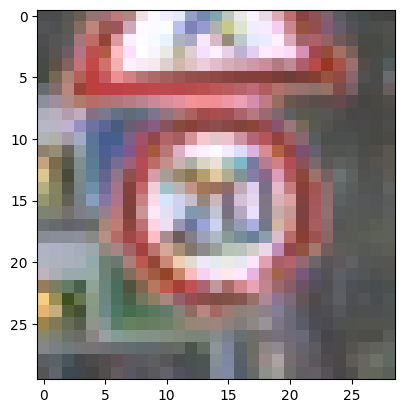

In [4]:
plt.imshow(img1)

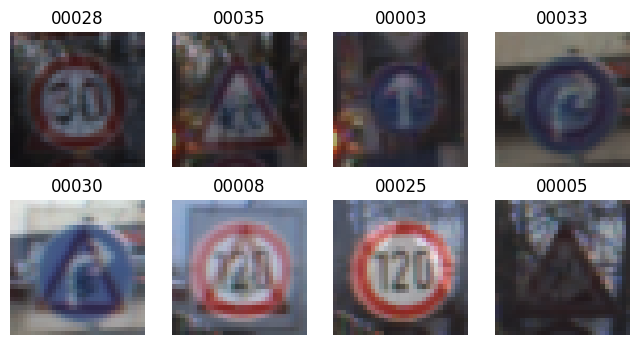

<Figure size 640x480 with 0 Axes>

Soft labels (MixUp):
tensor([[0.0000, 0.5940, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4060, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])


In [7]:
# -------------------------
# Transform base
# -------------------------
transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((IMG_SIZE, IMG_SIZE),antialias=True),
    v2.ToDtype(torch.float32,scale=True)
])

# -------------------------
# Dataset + loader
# -------------------------
train_set = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -------------------------
# MixUp (CORRIGIDO)
# -------------------------
mixup = v2.MixUp(num_classes=43, alpha=1.0)

# get batch
imgs, labels = next(iter(train_loader))

# apply mixup (batch level)
imgs2, labels2 = mixup(imgs, labels)

# -------------------------
# visualization
# -------------------------
vcpi_util.show_images(
    2,
    4,
    imgs2,
    labels,   # opcional (não ideal)
    train_set.classes
)

print("Soft labels (MixUp):")
print(labels2)